# Understanding Where and How Washington Residents Are Going Electric

## Introduction:

### The global transition toward sustainable transportation has accelerated in recent years, with electric vehicles (EVs) emerging as a cornerstone of efforts to reduce carbon emissions and dependence on fossil fuels. Washington State has been at the forefront of this shift in the United States, supported by state-level incentives, a progressive clean energy policy environment, and a tech-forward population concentrated in the greater Seattle area. This project leverages vehicle registration data from the Washington State Department of Licensing (DOL) to explore the geographic distribution and adoption trends of Battery Electric Vehicles (BEVs) and Plug-in Hybrid Electric Vehicles (PHEVs) across the state's counties and cities. Through exploratory data analysis and visualization, we examine which regions lead in EV adoption, how the composition of BEVs versus PHEVs varies across areas, and how registrations and electric range have evolved over time by model year. The insights generated here lay the groundwork for predictive modeling — including classification and clustering approaches — aimed at identifying the key factors that drive EV adoption patterns across Washington's diverse geographic and demographic landscape.

In [1]:
import pandas as pd
import numpy as np
%matplotlib inline                  
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
import seaborn as sns
import warnings
warnings.filterwarnings('ignore')

In [2]:
#Load data
file_path = "Electric_Vehicle_Population_Data.csv"
df = pd.read_csv(file_path)
df.head()

,VIN (1-10),County,City,State,Postal Code,Model Year,Make,Model,Electric Vehicle Type,Clean Alternative Fuel Vehicle (CAFV) Eligibility,Electric Range,Legislative District,DOL Vehicle ID,Vehicle Location,Electric Utility,2020 Census Tract
0,5YJ3E1EBXJ,Yakima,Yakima,WA,98902.0,2018,TESLA,MODEL 3,Battery Electric Vehicle (BEV),Clean Alternative Fuel Vehicle Eligible,215.0,14.0,131356970,POINT (-120.51904 46.59783),PACIFICORP,5.307700e+10
1,1N4BZ0CP2G,King,Kent,WA,98030.0,2016,NISSAN,LEAF,Battery Electric Vehicle (BEV),Clean Alternative Fuel Vehicle Eligible,84.0,33.0,211702123,POINT (-122.19975 47.37483),PUGET SOUND ENERGY INC||CITY OF TACOMA - (WA),5.303303e+10
2,1C4JJXP64P,Snohomish,Marysville,WA,98271.0,2023,JEEP,WRANGLER,Plug-in Hybrid Electric Vehicle (PHEV),Not eligible due to low battery range,21.0,38.0,238694900,POINT (-122.17138 48.10433),PUGET SOUND ENERGY INC,5.306194e+10
3,WA1E2AFY0S,Snohomish,Bothell,WA,98012.0,2025,AUDI,Q5 E,Plug-in Hybrid Electric Vehicle (PHEV),Not eligible due to low battery range,28.0,1.0,278444183,POINT (-122.20105 47.84423),PUGET SOUND ENERGY INC,5.306105e+10
4,1N4AZ0CPXG,King,Seattle,WA,98125.0,2016,NISSAN,LEAF,Battery Electric Vehicle (BEV),Clean Alternative Fuel Vehicle Eligible,84.0,46.0,252437846,POINT (-122.30253 47.72656),CITY OF SEATTLE - (WA)|CITY OF TACOMA - (WA),5.303300e+10


In [3]:
#Drop last column (2020 census tract)
df = df.drop(columns=['2020 Census Tract'])

In [4]:
#Keep vehicles in WA/remove vehicles located in other states
df = df[df['State'] == 'WA']

In [5]:
print(df['State'].value_counts())

State
WA    276144
Name: count, dtype: int64


In [6]:
#Drop State
df.drop(columns=['State'], inplace=True)

In [7]:
df.head()

,VIN (1-10),County,City,Postal Code,Model Year,Make,Model,Electric Vehicle Type,Clean Alternative Fuel Vehicle (CAFV) Eligibility,Electric Range,Legislative District,DOL Vehicle ID,Vehicle Location,Electric Utility
0,5YJ3E1EBXJ,Yakima,Yakima,98902.0,2018,TESLA,MODEL 3,Battery Electric Vehicle (BEV),Clean Alternative Fuel Vehicle Eligible,215.0,14.0,131356970,POINT (-120.51904 46.59783),PACIFICORP
1,1N4BZ0CP2G,King,Kent,98030.0,2016,NISSAN,LEAF,Battery Electric Vehicle (BEV),Clean Alternative Fuel Vehicle Eligible,84.0,33.0,211702123,POINT (-122.19975 47.37483),PUGET SOUND ENERGY INC||CITY OF TACOMA - (WA)
2,1C4JJXP64P,Snohomish,Marysville,98271.0,2023,JEEP,WRANGLER,Plug-in Hybrid Electric Vehicle (PHEV),Not eligible due to low battery range,21.0,38.0,238694900,POINT (-122.17138 48.10433),PUGET SOUND ENERGY INC
3,WA1E2AFY0S,Snohomish,Bothell,98012.0,2025,AUDI,Q5 E,Plug-in Hybrid Electric Vehicle (PHEV),Not eligible due to low battery range,28.0,1.0,278444183,POINT (-122.20105 47.84423),PUGET SOUND ENERGY INC
4,1N4AZ0CPXG,King,Seattle,98125.0,2016,NISSAN,LEAF,Battery Electric Vehicle (BEV),Clean Alternative Fuel Vehicle Eligible,84.0,46.0,252437846,POINT (-122.30253 47.72656),CITY OF SEATTLE - (WA)|CITY OF TACOMA - (WA)


In [8]:
# Style Config
COLORS = {
    'primary':   '#1B4FD8',
    'secondary': '#10B981',
    'accent':    '#F59E0B',
    'danger':    '#EF4444',
    'bg':        '#F8FAFC',
    'text':      '#1E293B',
    'grid':      '#E2E8F0',
}

BEV_COLOR  = COLORS['primary']
PHEV_COLOR = COLORS['secondary']

In [9]:
plt.rcParams.update({
    'figure.facecolor':  COLORS['bg'],
    'axes.facecolor':    COLORS['bg'],
    'axes.edgecolor':    COLORS['grid'],
    'axes.labelcolor':   COLORS['text'],
    'axes.titlecolor':   COLORS['text'],
    'axes.titlesize':    13,
    'axes.labelsize':    11,
    'xtick.color':       COLORS['text'],
    'ytick.color':       COLORS['text'],
    'grid.color':        COLORS['grid'],
    'grid.linestyle':    '--',
    'grid.alpha':        0.7,
    'font.family':       'DejaVu Sans',
    'text.color':        COLORS['text'],
})

In [10]:
def savefig(name):
    plt.tight_layout()
    plt.savefig(f"{name}.png", dpi=150, bbox_inches='tight', facecolor=COLORS['bg'])
    plt.show()    # ← show before close
    plt.close()
    print(f"  ✓ Saved {name}.png")

In [11]:
# Simplify EV type label
df['EV Type'] = df['Electric Vehicle Type'].map({
    'Battery Electric Vehicle (BEV)':           'BEV',
    'Plug-in Hybrid Electric Vehicle (PHEV)':   'PHEV',
})

In [12]:
print(f"  Rows: {len(df):,}  |  Counties: {df['County'].nunique()}  |  Cities: {df['City'].nunique()}")
print()

  Rows: 276,144  |  Counties: 39  |  Cities: 495



### 1. Top 15 Counties by Total Registrations
This chart ranks the 15 Washington counties with the highest number of registered electric vehicles. It gives a high-level view of where EV adoption is most concentrated geographically. Counties like King (Seattle) are expected to dominate, reflecting the link between urban population density and EV uptake.

Plot 1: Top counties...


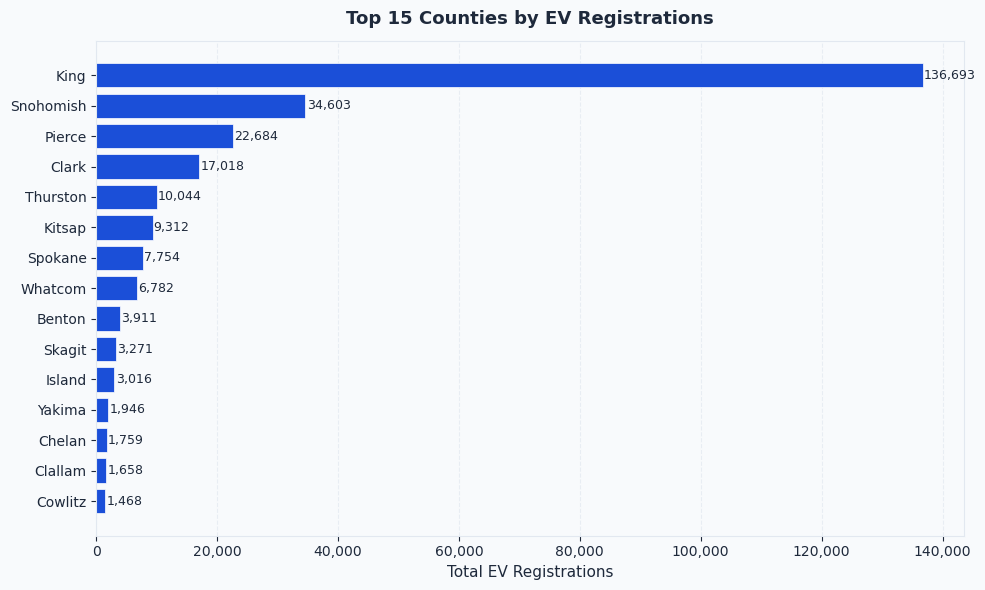

  ✓ Saved plot1_top_counties.png


In [13]:
#1. Top 15 Counties by Total Registrations
print("Plot 1: Top counties...")
county_counts = df['County'].value_counts().head(15)

fig, ax = plt.subplots(figsize=(10, 6))
bars = ax.barh(county_counts.index[::-1], county_counts.values[::-1],
               color=COLORS['primary'], edgecolor='white', linewidth=0.5)
for bar, val in zip(bars, county_counts.values[::-1]):
    ax.text(bar.get_width() + 200, bar.get_y() + bar.get_height()/2,
            f'{val:,}', va='center', fontsize=9, color=COLORS['text'])
ax.set_xlabel('Total EV Registrations')
ax.set_title('Top 15 Counties by EV Registrations', fontweight='bold', pad=12)
ax.xaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f'{int(x):,}'))
ax.grid(axis='x')
ax.set_axisbelow(True)
savefig("plot1_top_counties")

### 2. Top 15 Cities by Total Registrations
This narrows the geographic lens from county to city level, showing which individual cities have the most EVs registered. It helps identify whether adoption is driven by a few major urban centers or spread across many mid-sized cities. This is useful for spotting city-level infrastructure needs like charging stations.

Plot 2: Top cities...


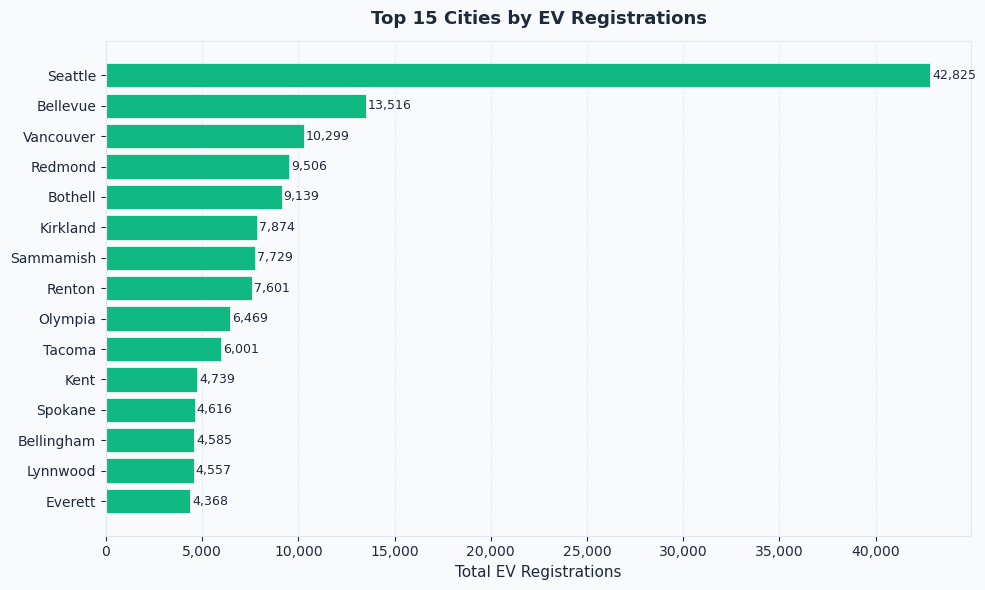

  ✓ Saved plot2_top_cities.png


In [14]:
# 2. Top 15 Cities 
print("Plot 2: Top cities...")
city_counts = df['City'].value_counts().head(15)

fig, ax = plt.subplots(figsize=(10, 6))
bars = ax.barh(city_counts.index[::-1], city_counts.values[::-1],
               color=COLORS['secondary'], edgecolor='white', linewidth=0.5)
for bar, val in zip(bars, city_counts.values[::-1]):
    ax.text(bar.get_width() + 100, bar.get_y() + bar.get_height()/2,
            f'{val:,}', va='center', fontsize=9, color=COLORS['text'])
ax.set_xlabel('Total EV Registrations')
ax.set_title('Top 15 Cities by EV Registrations', fontweight='bold', pad=12)
ax.xaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f'{int(x):,}'))
ax.grid(axis='x')
ax.set_axisbelow(True)
savefig("plot2_top_cities")

### 3. BEV vs PHEV Split — Top 10 Counties
This stacked bar chart breaks down each top county's registrations into Battery Electric Vehicles (fully electric) and Plug-in Hybrids (partial electric). It reveals whether counties lean toward full electrification or still favor the transitional hybrid option. Regional differences here could reflect income levels, charging infrastructure availability, or local dealer presence.

Plot 3: BEV vs PHEV by county...


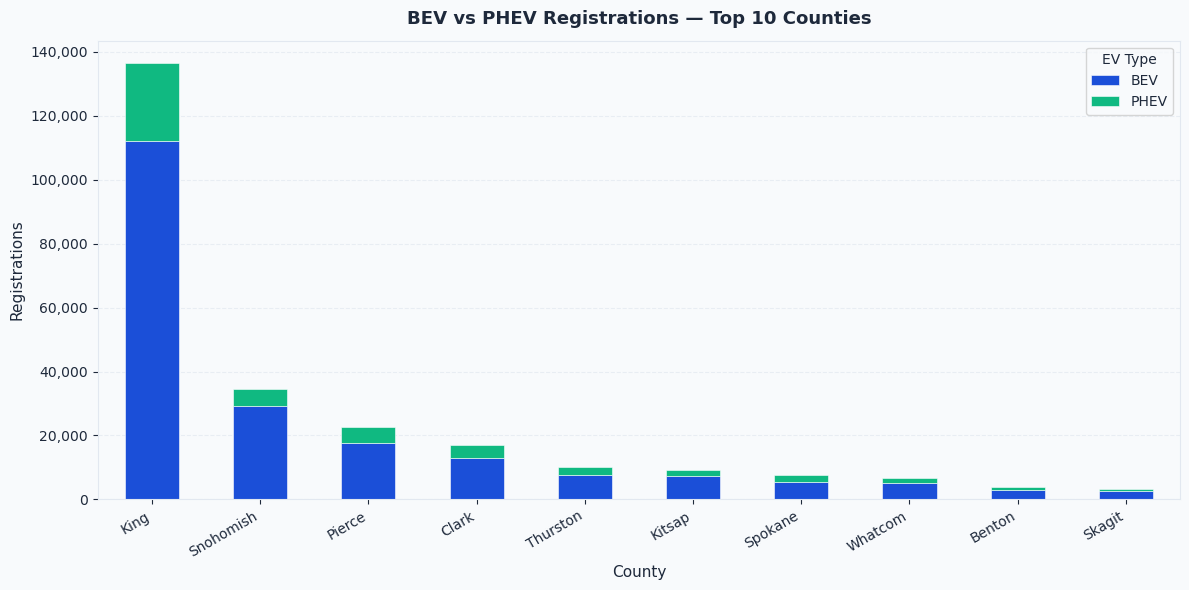

  ✓ Saved plot3_bev_phev_county.png


In [15]:
# 3. BEV vs PHEV Split — Top 10 Counties (Stacked Bar)
print("Plot 3: BEV vs PHEV by county...")
top10_counties = df['County'].value_counts().head(10).index
county_type = (df[df['County'].isin(top10_counties)]
               .groupby(['County', 'EV Type'])
               .size().unstack(fill_value=0)
               .loc[top10_counties])  # preserve rank order

fig, ax = plt.subplots(figsize=(12, 6))
county_type.plot(kind='bar', stacked=True, ax=ax,
                 color=[BEV_COLOR, PHEV_COLOR], edgecolor='white', linewidth=0.4)
ax.set_title('BEV vs PHEV Registrations — Top 10 Counties', fontweight='bold', pad=12)
ax.set_xlabel('County')
ax.set_ylabel('Registrations')
ax.yaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f'{int(x):,}'))
ax.legend(title='EV Type', loc='upper right')
ax.set_xticklabels(ax.get_xticklabels(), rotation=30, ha='right')
ax.grid(axis='y')
ax.set_axisbelow(True)
savefig("plot3_bev_phev_county")

### 4. Year-over-Year Growth by Model Year
This line chart tracks how many BEVs and PHEVs were registered per model year, showing the growth trajectory of EV adoption over time. It captures the acceleration point where EVs moved from niche to mainstream, and whether BEVs or PHEVs drove that growth. A diverging trend between the two types signals a market shift toward full electrification.

Plot 4: YoY growth by model year...


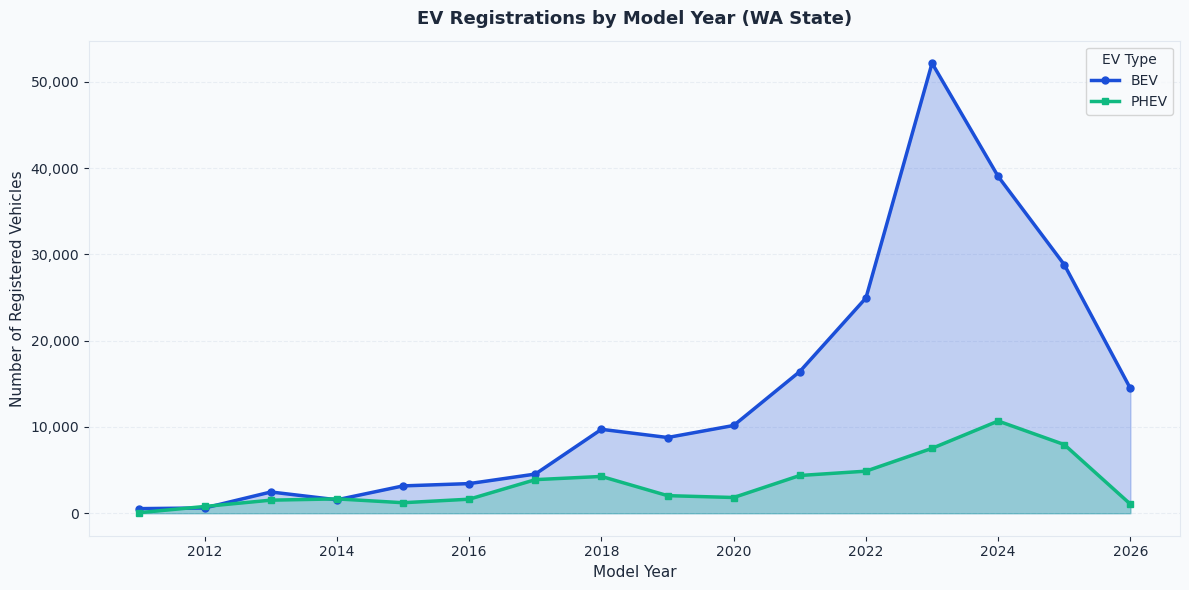

  ✓ Saved plot4_yoy_growth.png


In [16]:
# 4. Year-over-Year Growth (Registrations by Model Year)
print("Plot 4: YoY growth by model year...")
year_type = (df[df['Model Year'] >= 2011]
             .groupby(['Model Year', 'EV Type'])
             .size().unstack(fill_value=0))

fig, ax = plt.subplots(figsize=(12, 6))
ax.fill_between(year_type.index, year_type.get('BEV', 0),
                alpha=0.25, color=BEV_COLOR)
ax.fill_between(year_type.index, year_type.get('PHEV', 0),
                alpha=0.25, color=PHEV_COLOR)
ax.plot(year_type.index, year_type.get('BEV', 0),
        marker='o', color=BEV_COLOR, linewidth=2.5, label='BEV', markersize=5)
ax.plot(year_type.index, year_type.get('PHEV', 0),
        marker='s', color=PHEV_COLOR, linewidth=2.5, label='PHEV', markersize=5)
ax.set_title('EV Registrations by Model Year (WA State)', fontweight='bold', pad=12)
ax.set_xlabel('Model Year')
ax.set_ylabel('Number of Registered Vehicles')
ax.yaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f'{int(x):,}'))
ax.legend(title='EV Type')
ax.grid(axis='y')
ax.set_axisbelow(True)
savefig("plot4_yoy_growth")

### 5. Average Electric Range by Model Year
This chart measures how the average electric driving range of registered vehicles has changed across model years. It directly reflects technological progress in battery capacity — a key barrier to EV adoption. Separating BEV and PHEV lines is important here since PHEVs naturally have a much shorter electric-only range by design.

Plot 5: Avg range by model year...


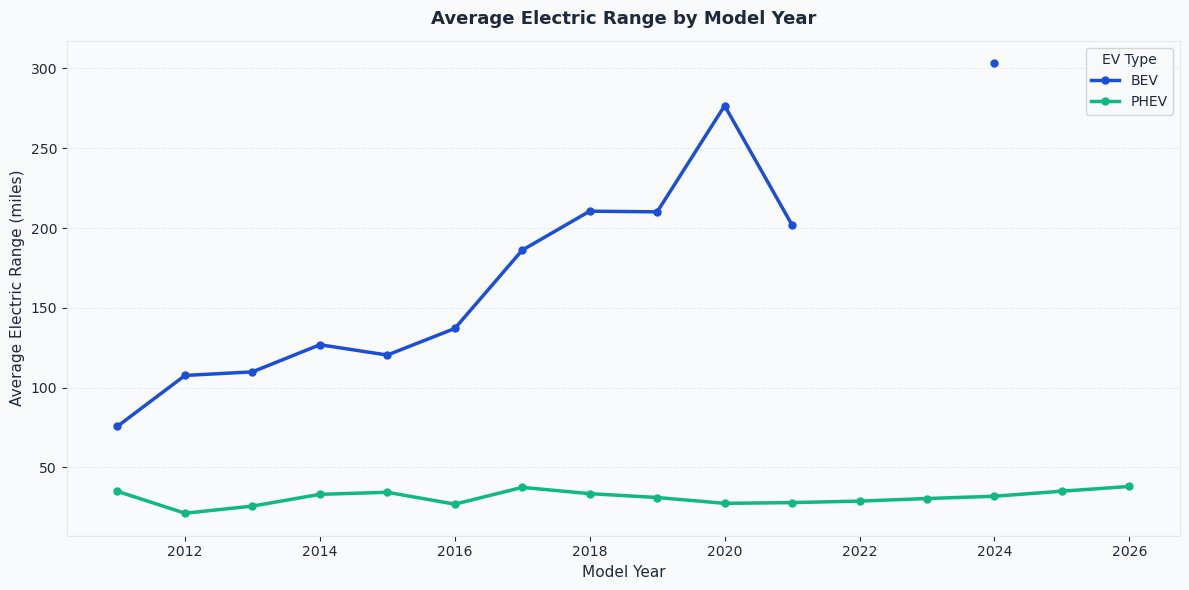

  ✓ Saved plot5_avg_range_year.png


In [17]:
# 5. Average Electric Range by Model Year
print("Plot 5: Avg range by model year...")
range_year = (df[(df['Model Year'] >= 2011) & (df['Electric Range'] > 0)]
              .groupby(['Model Year', 'EV Type'])['Electric Range']
              .mean().unstack())

fig, ax = plt.subplots(figsize=(12, 6))
for ev_type, color in [('BEV', BEV_COLOR), ('PHEV', PHEV_COLOR)]:
    if ev_type in range_year.columns:
        ax.plot(range_year.index, range_year[ev_type],
                marker='o', color=color, linewidth=2.5, label=ev_type, markersize=5)
ax.set_title('Average Electric Range by Model Year', fontweight='bold', pad=12)
ax.set_xlabel('Model Year')
ax.set_ylabel('Average Electric Range (miles)')
ax.legend(title='EV Type')
ax.grid(axis='y')
ax.set_axisbelow(True)
savefig("plot5_avg_range_year")

### 6. Top 10 Makes Overall
This bar chart shows which vehicle manufacturers have the most EVs registered in Washington State. It highlights market concentration — for example, whether Tesla dominates or if legacy automakers like Nissan, Chevrolet, and Ford have significant share. This is useful context for understanding brand-driven adoption patterns.

Plot 6: Top makes...


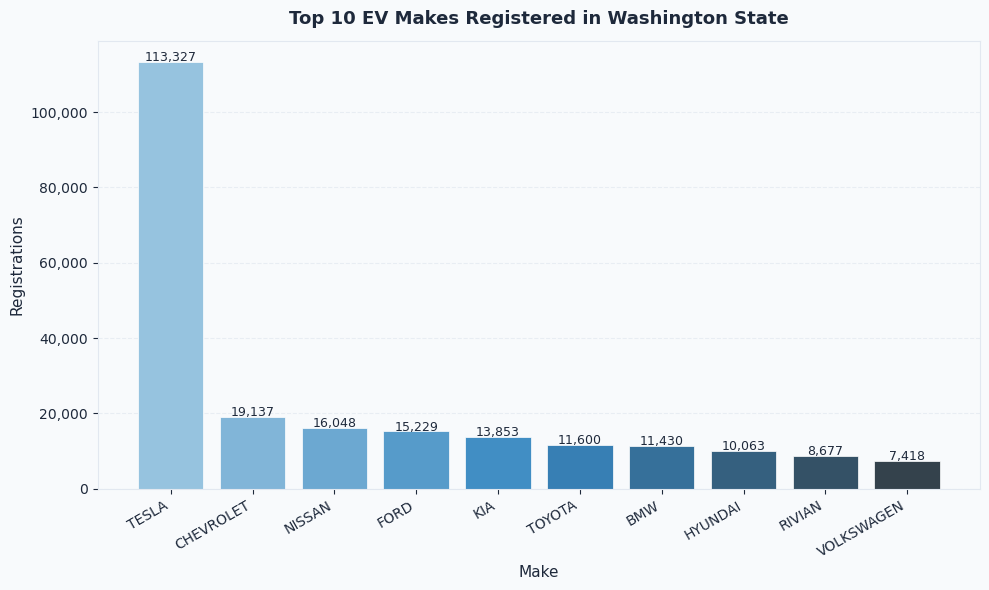

  ✓ Saved plot6_top_makes.png


In [18]:
# 6. Top 10 Makes Overall
print("Plot 6: Top makes...")
make_counts = df['Make'].value_counts().head(10)

fig, ax = plt.subplots(figsize=(10, 6))
palette = sns.color_palette("Blues_d", len(make_counts))
bars = ax.bar(make_counts.index, make_counts.values,
              color=palette, edgecolor='white', linewidth=0.5)
for bar, val in zip(bars, make_counts.values):
    ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 200,
            f'{val:,}', ha='center', fontsize=9, color=COLORS['text'])
ax.set_title('Top 10 EV Makes Registered in Washington State', fontweight='bold', pad=12)
ax.set_xlabel('Make')
ax.set_ylabel('Registrations')
ax.yaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f'{int(x):,}'))
ax.set_xticklabels(ax.get_xticklabels(), rotation=30, ha='right')
ax.grid(axis='y')
ax.set_axisbelow(True)
savefig("plot6_top_makes")

### 7. CAFV Eligibility Distribution
This pie chart shows what proportion of registered EVs qualify as Clean Alternative Fuel Vehicles under Washington State's eligibility criteria. Eligibility is largely determined by electric range, so a large "not eligible" or "unknown" slice points to older or shorter-range vehicles in the fleet. This metric matters for policy analysis since CAFV status often determines access to tax incentives and HOV lane privileges.

Plot 7: CAFV eligibility...


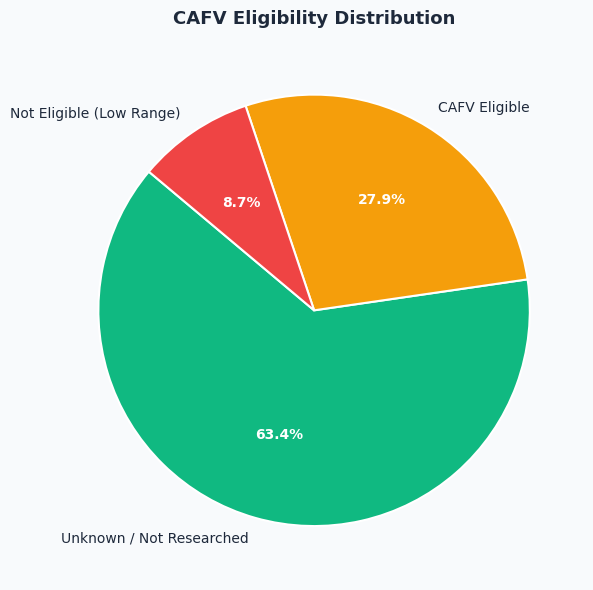

  ✓ Saved plot7_cafv_eligibility.png


In [19]:
# 7. CAFV Eligibility Breakdown 
print("Plot 7: CAFV eligibility...")
cafv_col = 'Clean Alternative Fuel Vehicle (CAFV) Eligibility'
cafv_counts = df[cafv_col].value_counts()
short_labels = [l.replace('Clean Alternative Fuel Vehicle Eligible', 'CAFV Eligible')
                 .replace('Eligibility unknown as battery range has not been researched', 'Unknown / Not Researched')
                 .replace('Not eligible due to low battery range', 'Not Eligible (Low Range)')
                for l in cafv_counts.index]

ig, ax = plt.subplots(figsize=(8, 6))
wedge_colors = [COLORS['secondary'], COLORS['accent'], COLORS['danger']]
wedges, texts, autotexts = ax.pie(
    cafv_counts.values,
    labels=short_labels,
    autopct='%1.1f%%',
    colors=wedge_colors[:len(cafv_counts)],
    startangle=140,
    wedgeprops={'edgecolor': 'white', 'linewidth': 1.5},
)
for t in autotexts:
    t.set_fontsize(10)
    t.set_color('white')
    t.set_fontweight('bold')
ax.set_title('CAFV Eligibility Distribution', fontweight='bold', pad=12)
savefig("plot7_cafv_eligibility")

### 8. BEV Share (%) by County
This chart shows, for each county, what percentage of its registered EVs are fully battery electric rather than plug-in hybrids. It moves beyond raw counts to reveal the quality of electrification — a county with 90% BEV share is further along the transition than one with mostly PHEVs. The dashed average line makes it easy to identify which counties are leading or lagging the state norm.

Plot 8: BEV share by county...


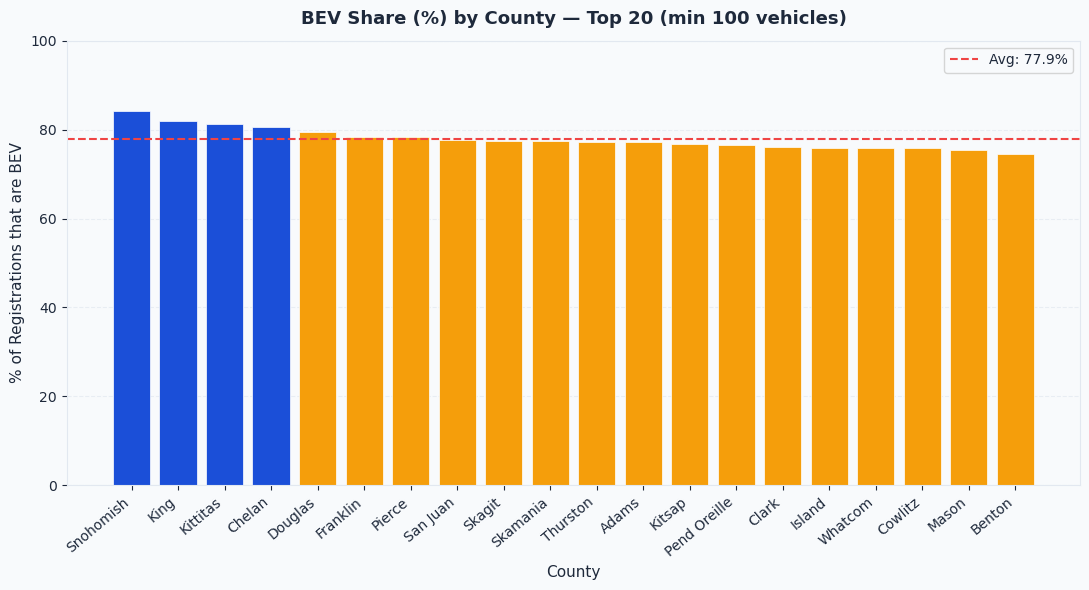

  ✓ Saved plot8_bev_share_county.png

✅ All 8 plots saved successfully.


In [20]:
# 8. BEV Share by County (Top 20)
print("Plot 8: BEV share by county...")
county_ev = df.groupby(['County', 'EV Type']).size().unstack(fill_value=0)
county_ev['Total'] = county_ev.sum(axis=1)
county_ev['BEV_Share'] = county_ev.get('BEV', 0) / county_ev['Total'] * 100
top20 = county_ev[county_ev['Total'] >= 100].sort_values('BEV_Share', ascending=False).head(20)

fig, ax = plt.subplots(figsize=(11, 6))
bar_colors = [BEV_COLOR if s >= 80 else COLORS['accent'] if s >= 60 else PHEV_COLOR
              for s in top20['BEV_Share']]
bars = ax.bar(top20.index, top20['BEV_Share'], color=bar_colors,
              edgecolor='white', linewidth=0.5)
ax.axhline(top20['BEV_Share'].mean(), color=COLORS['danger'],
           linestyle='--', linewidth=1.5, label=f"Avg: {top20['BEV_Share'].mean():.1f}%")
ax.set_title('BEV Share (%) by County — Top 20 (min 100 vehicles)', fontweight='bold', pad=12)
ax.set_xlabel('County')
ax.set_ylabel('% of Registrations that are BEV')
ax.set_ylim(0, 100)
ax.legend()
ax.set_xticklabels(ax.get_xticklabels(), rotation=40, ha='right')
ax.grid(axis='y')
ax.set_axisbelow(True)
savefig("plot8_bev_share_county")

print("\n✅ All 8 plots saved successfully.")

In [21]:
# Summary Stats 
print("\n── Summary Statistics ──────────────────────────────────────────────")
print(f"Total vehicles:        {len(df):,}")
print(f"BEV:                   {(df['EV Type']=='BEV').sum():,}  ({(df['EV Type']=='BEV').mean()*100:.1f}%)")
print(f"PHEV:                  {(df['EV Type']=='PHEV').sum():,}  ({(df['EV Type']=='PHEV').mean()*100:.1f}%)")
print(f"Counties covered:      {df['County'].nunique()}")
print(f"Unique makes:          {df['Make'].nunique()}")
print(f"Model year range:      {df['Model Year'].min()} – {df['Model Year'].max()}")
print(f"Avg electric range:    {df[df['Electric Range']>0]['Electric Range'].mean():.1f} miles")
print(f"Top county:            {df['County'].value_counts().index[0]}  ({df['County'].value_counts().iloc[0]:,} vehicles)")
print(f"Top city:              {df['City'].value_counts().index[0]}  ({df['City'].value_counts().iloc[0]:,} vehicles)")



── Summary Statistics ──────────────────────────────────────────────
Total vehicles:        276,144
BEV:                   220,821  (80.0%)
PHEV:                  55,323  (20.0%)
Counties covered:      39
Unique makes:          47
Model year range:      1999 – 2026
Avg electric range:    107.8 miles
Top county:            King  (136,693 vehicles)
Top city:              Seattle  (42,825 vehicles)
